<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [98]:
# Your code 
df = pd.read_csv("./data/College.csv")
df = df.rename(columns={'Unnamed: 0': 'University / College'})
df.head()

,University / College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [99]:
# Your code here
df.shape

(777, 19)

In [100]:
df.dtypes

University / College        str
Private                     str
Apps                      int64
Accept                    int64
Enroll                    int64
Top10perc                 int64
Top25perc                 int64
F.Undergrad               int64
P.Undergrad               int64
Outstate                  int64
Room.Board                int64
Books                     int64
Personal                  int64
PhD                         str
Terminal                  int64
S.F.Ratio               float64
perc.alumni               int64
Expend                    int64
Grad.Rate                 int64
dtype: object

In [101]:
df.isna().sum()

University / College    0
Private                 0
Apps                    0
Accept                  0
Enroll                  0
Top10perc               0
Top25perc               0
F.Undergrad             0
P.Undergrad             0
Outstate                0
Room.Board              0
Books                   0
Personal                0
PhD                     0
Terminal                0
S.F.Ratio               0
perc.alumni             0
Expend                  0
Grad.Rate               0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [102]:
# Your code here
df['PhD'] = pd.to_numeric(df['PhD'], errors='coerce')

print("Entries above 100:", (df['PhD'] > 100).sum())
print("Entries below 0:", (df['PhD'] < 0).sum())

phd_median = df.loc[df['PhD'] <= 100, 'PhD'].median()

df.loc[df['PhD'] > 100, 'PhD'] = phd_median

Entries above 100: 1
Entries below 0: 0


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [103]:
# Your code here
df['Grad.Rate'] = pd.to_numeric(df['Grad.Rate'], errors='coerce')

print("Entries above 100:", (df['Grad.Rate'] > 100).sum())
print("Entries below 0:", (df['Grad.Rate'] < 0).sum())

df.loc[df['Grad.Rate'] > 100, 'Grad.Rate'] = 100

Entries above 100: 1
Entries below 0: 0


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [104]:

%%writefile myutils.py
import numpy as np
import pandas as pd


def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """

    results = []

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:

        # Skip binary and ID columns
        if df[col].nunique() <= 2:
            continue

        if "id" in col.lower():
            continue

        skew = df[col].dropna().skew()

        # Degree
        if abs(skew) < 0.5:
            degree = "Approximately Symmetric"
            recommendation = "None needed"

        elif abs(skew) < 1:
            degree = "Moderately Skewed"

            if skew > 0:
                recommendation = "log(x+1) or Yeo-Johnson"
            else:
                recommendation = "Box-Cox or Yeo-Johnson"

        else:
            degree = "Highly Skewed"
            recommendation = "Box-Cox or Yeo-Johnson"

        # Direction
        if skew >= 0:
            direction = "Positive"
        else:
            direction = "Negative"

        results.append({
            "Feature": col,
            "Skewness": skew,
            "Degree": degree,
            "Direction": direction,
            "Recommended Transformation": recommendation
        })

    return pd.DataFrame(results)

Overwriting myutils.py


In [105]:
# Now import the function from myutils
from myutils import skew_calc

In [106]:
import matplotlib.pyplot as plt
from scipy.stats import boxcox, yeojohnson

def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
    for _, row in skew_table.iterrows():
        feature = row.get('Column', row.get('Feature'))
        recommendation = row.get('Recommendation', row.get('Recommended Transformation'))

        if recommendation in ['None needed', 'None']:
            continue

        original = df[feature].dropna()
        transformed = original.copy()
        method_used = "Box-Cox"

        try:
            if original.min() > 0:
                transformed, _ = boxcox(original)
                method_used = 'Box-Cox'
            else:
                pt = PowerTransformer(method='yeo-johnson')
                transformed = pt.fit_transform(original.values.reshape(-1, 1)).flatten()
                method_used = 'Yeo-Johnson'
        except Exception as e:
            print(f"Error transforming {feature}: {e}")
            continue

        orig_skew = original.skew()
        trans_skew = pd.Series(transformed).skew()

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Original Plot
        sns.histplot(original, kde=True, ax=axes[0], color='#4c82b4')
        axes[0].set_title(f'Original {feature}\n(Skew: {orig_skew:.2f})')
        axes[0].set_xlabel(feature)

        # Transformed Plot
        sns.histplot(transformed, kde=True, ax=axes[1], color='#4c82b4')
        axes[1].set_title(f'Best transformation: {method_used} for {feature}\n(Skew: {trans_skew:.2f})')

        plt.tight_layout()
        plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [107]:
# Your code here
skew_table = skew_calc(df)
skew_table


,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,log(x+1) or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


In [108]:
# Your code here

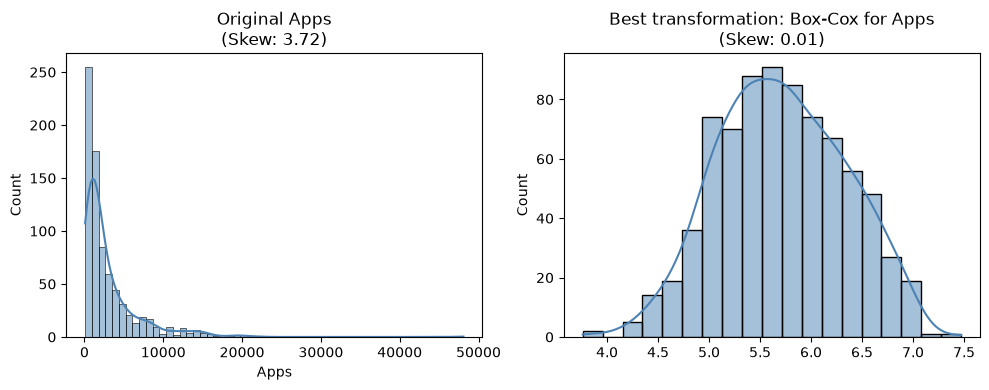

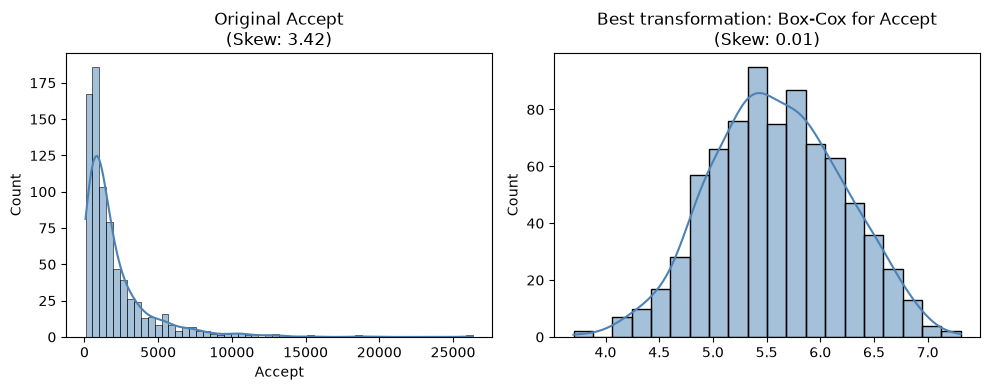

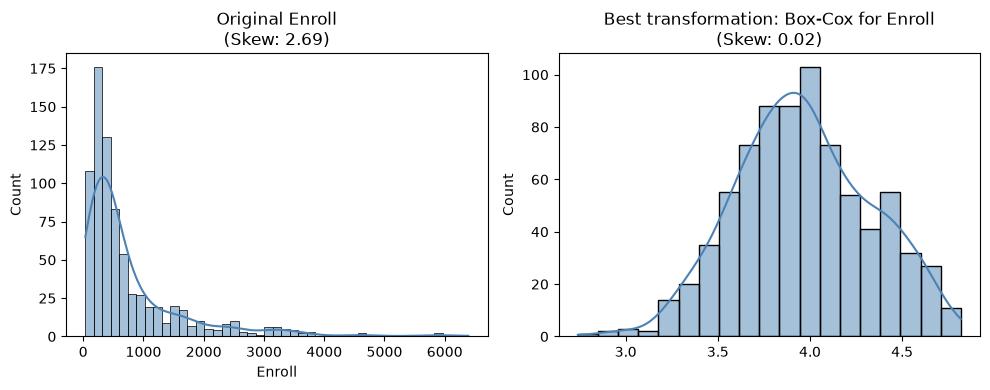

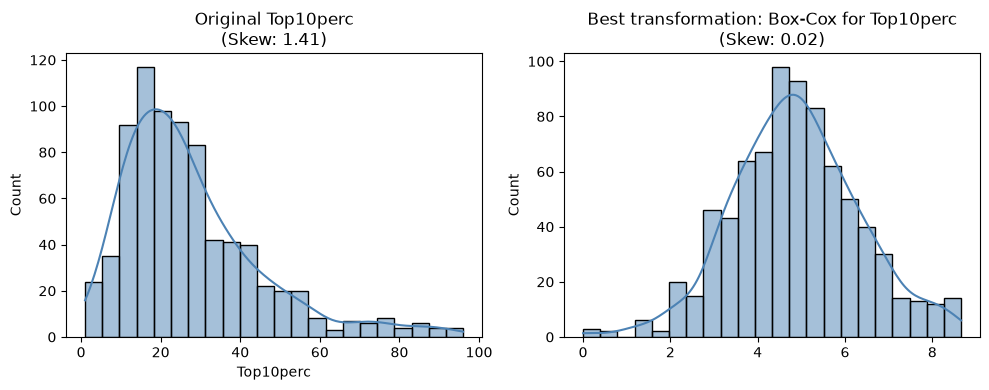

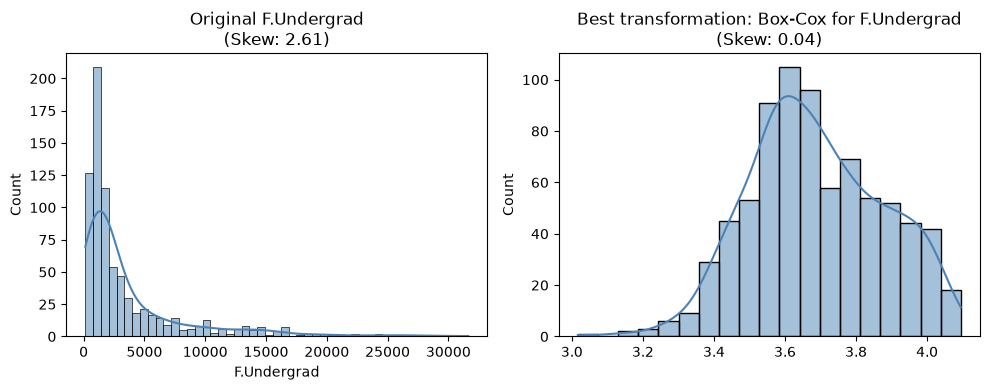

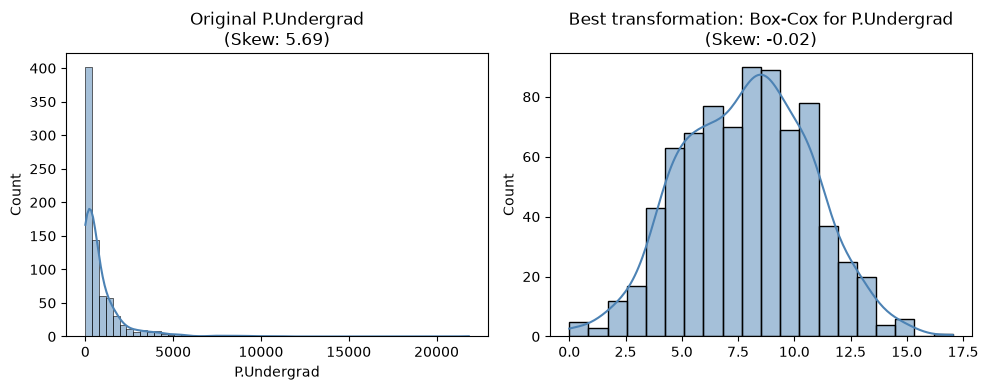

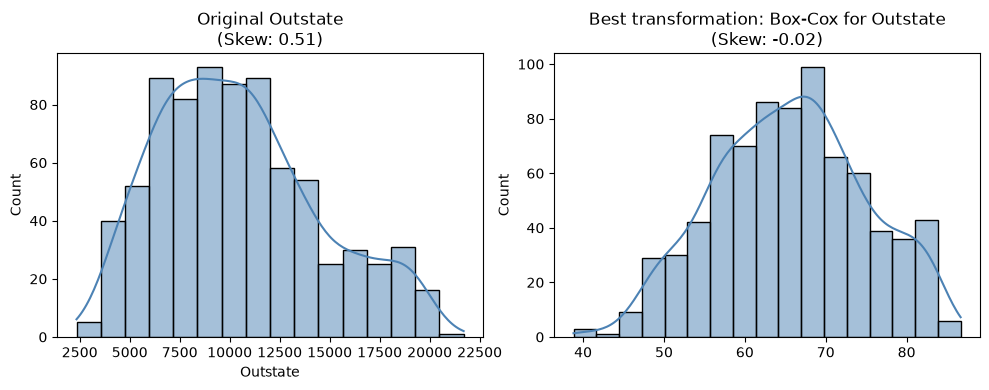

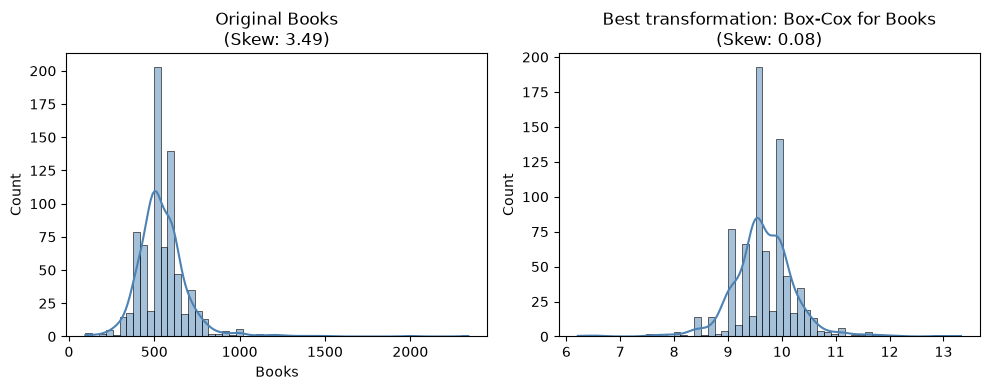

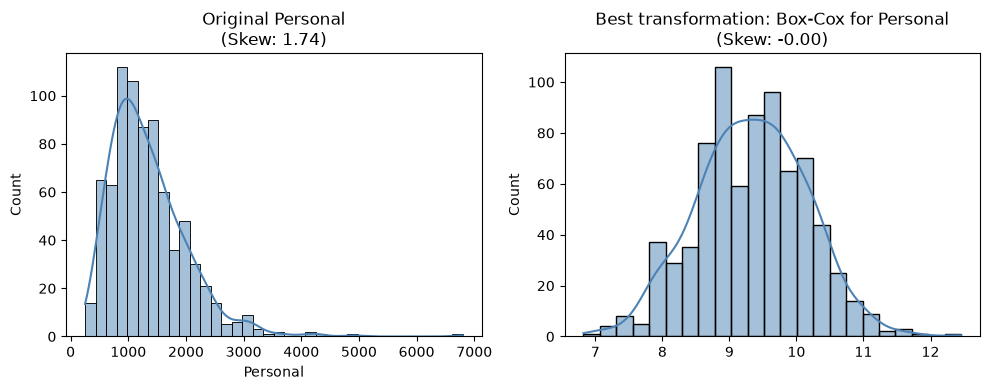

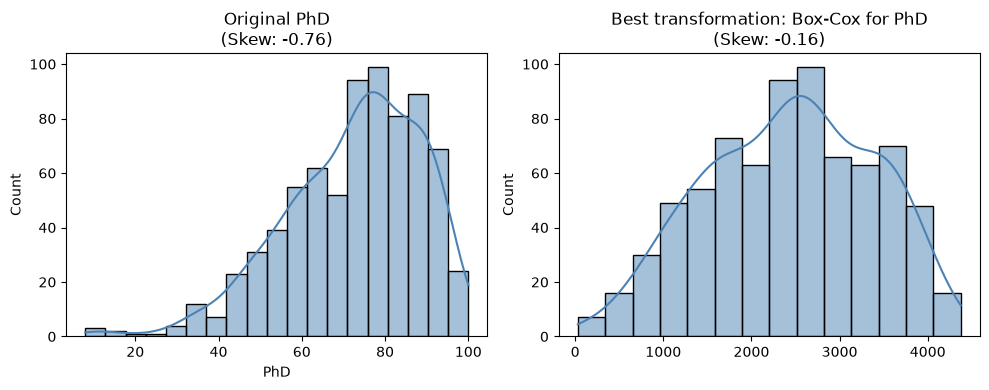

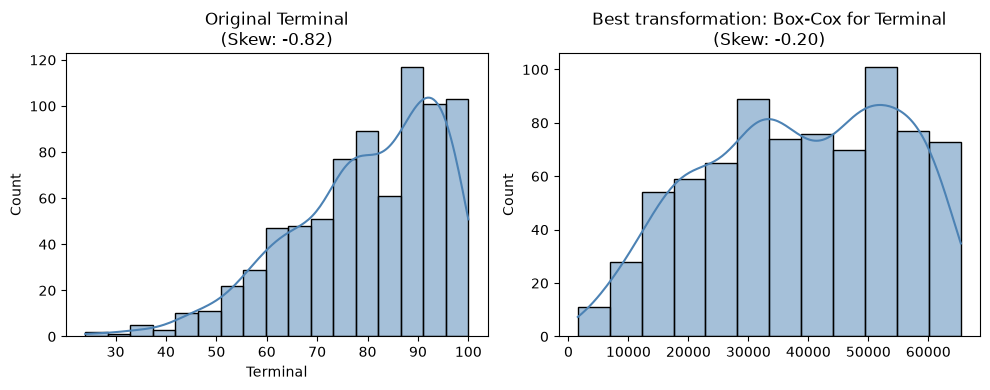

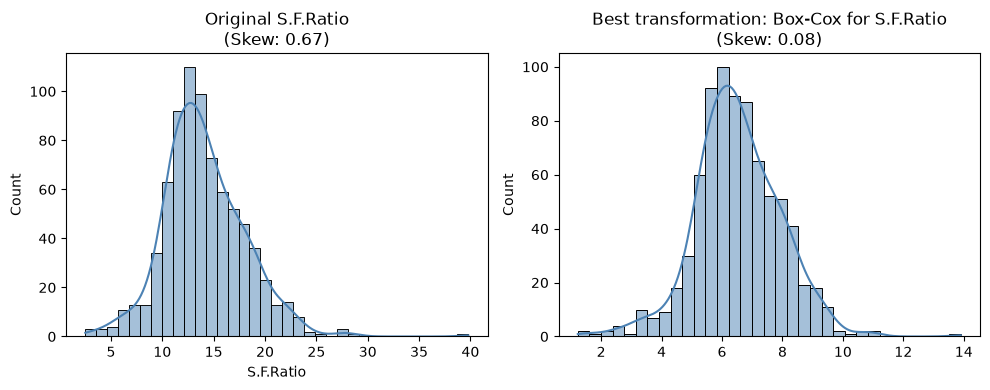

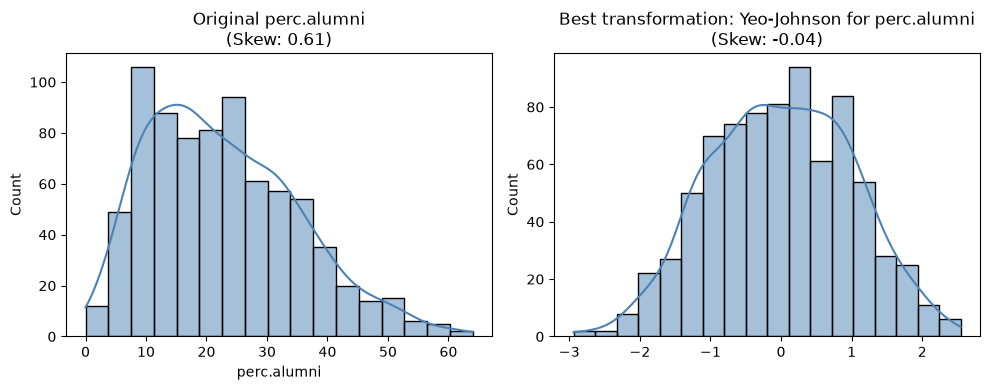

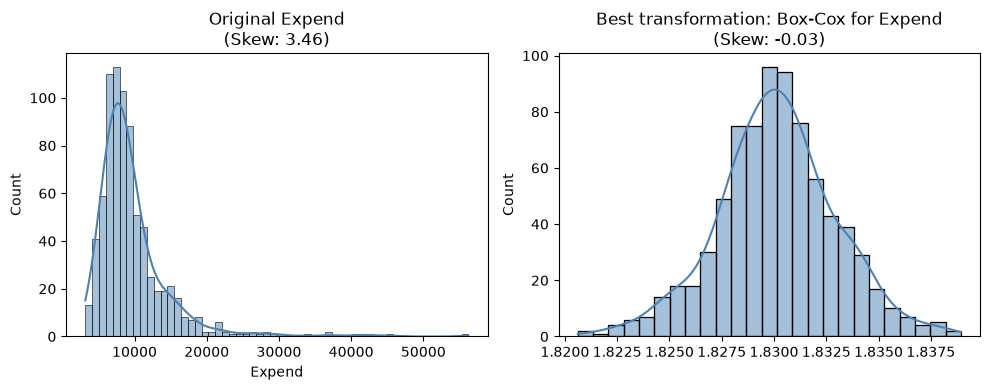

In [109]:
# Your code here
plot_transformations(df, skew_table)


In [110]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [111]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

trans_cols = []

for _, row in skew_table.iterrows():

    col = row["Feature"]
    method = row["Recommended Transformation"]

    if method == "None needed":
        continue

    new_col = f"{col}_trans"

    if method == "log(x+1) or Yeo-Johnson":
        df[new_col] = np.log1p(df[col])

    elif method == "Box-Cox or Yeo-Johnson":

        if (df[col] > 0).all():
            pt = PowerTransformer(method="box-cox")
        else:
            pt = PowerTransformer(method="yeo-johnson")

        df[new_col] = pt.fit_transform(df[[col]]).flatten()

    trans_cols.append(new_col)

print("Transformed columns:", trans_cols)

df[trans_cols].head()

Transformed columns: ['Apps_trans', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 'F.Undergrad_trans', 'P.Undergrad_trans', 'Outstate_trans', 'Books_trans', 'Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Expend_trans']


,Apps_trans,Accept_trans,Enroll_trans,Top10perc_trans,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,8.914761,-0.614254,1.271398,-0.279508,-0.282374,2.949688,2.564949,-0.491183
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,9.415809,1.302365,0.456551,-2.150359,-2.248129,2.580217,2.833213,0.552362
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,9.328212,-1.038575,-0.068655,-1.237794,-1.040711,2.631889,3.433987,0.096393
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,9.469700,-0.614254,-0.651734,1.343252,1.364588,2.163323,3.637586,1.726997
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,8.930759,1.553608,0.456551,0.120295,-0.687052,2.557227,1.098612,0.637044


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [112]:
# Your code here 
df['Accept_Rate'] = df['Accept'] / df['Apps']
df[['Apps', 'Accept', 'Accept_Rate']].head()


,Apps,Accept,Accept_Rate
0,1660,1232,0.742169
1,2186,1924,0.880146
2,1428,1097,0.768207
3,417,349,0.836930
4,193,146,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [113]:
bins = [0, 7000, 12000, 17000, 22000]
labels = ['Low', 'Medium', 'High', 'Very High']

df['Outstate_Tier'] = pd.cut(
    df['Outstate'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[['Outstate', 'Outstate_Tier']].head()

,Outstate,Outstate_Tier
0,7440,Medium
1,12280,High
2,11250,Medium
3,12960,High
4,7560,Medium


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [114]:
tier_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

df['Outstate_Tier_Encoded'] = df['Outstate_Tier'].map(tier_mapping)

df[['Outstate', 'Outstate_Tier', 'Outstate_Tier_Encoded']].head()

,Outstate,Outstate_Tier,Outstate_Tier_Encoded
0,7440,Medium,2
1,12280,High,3
2,11250,Medium,2
3,12960,High,3
4,7560,Medium,2


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [115]:
df["Private_Encoded"] = df["Private"].map({
    "Yes": 1,
    "No": 0
})

df[["Private", "Private_Encoded"]].head()

,Private,Private_Encoded
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [116]:
scale_cols = trans_cols + ["Outstate_Tier_Encoded", "Private_Encoded"]

scaler = StandardScaler()

scaled_values = scaler.fit_transform(df[scale_cols])

for i, col in enumerate(scale_cols):
    df[col + "_scaled"] = scaled_values[:, i]

df[[col + "_scaled" for col in scale_cols]].head()

,Apps_trans_scaled,Accept_trans_scaled,Enroll_trans_scaled,Top10perc_trans_scaled,F.Undergrad_trans_scaled,P.Undergrad_trans_scaled,Outstate_trans_scaled,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Outstate_Tier_Encoded_scaled,Private_Encoded_scaled
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,-0.644735,-0.614254,1.271398,-0.279508,-0.282374,0.985238,-0.722701,-0.491183,-0.193717,0.612553
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,0.593238,1.302365,0.456551,-2.150359,-2.248129,-0.355634,-0.284489,0.552362,0.946570,0.612553
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,0.376808,-1.038575,-0.068655,-1.237794,-1.040711,-0.168108,0.696881,0.096393,-0.193717,0.612553
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,0.726391,-0.614254,-0.651734,1.343252,1.364588,-1.868608,1.029462,1.726997,0.946570,0.612553
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,-0.605207,1.553608,0.456551,0.120295,-0.687052,-0.439066,-3.117978,0.637044,-0.193717,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

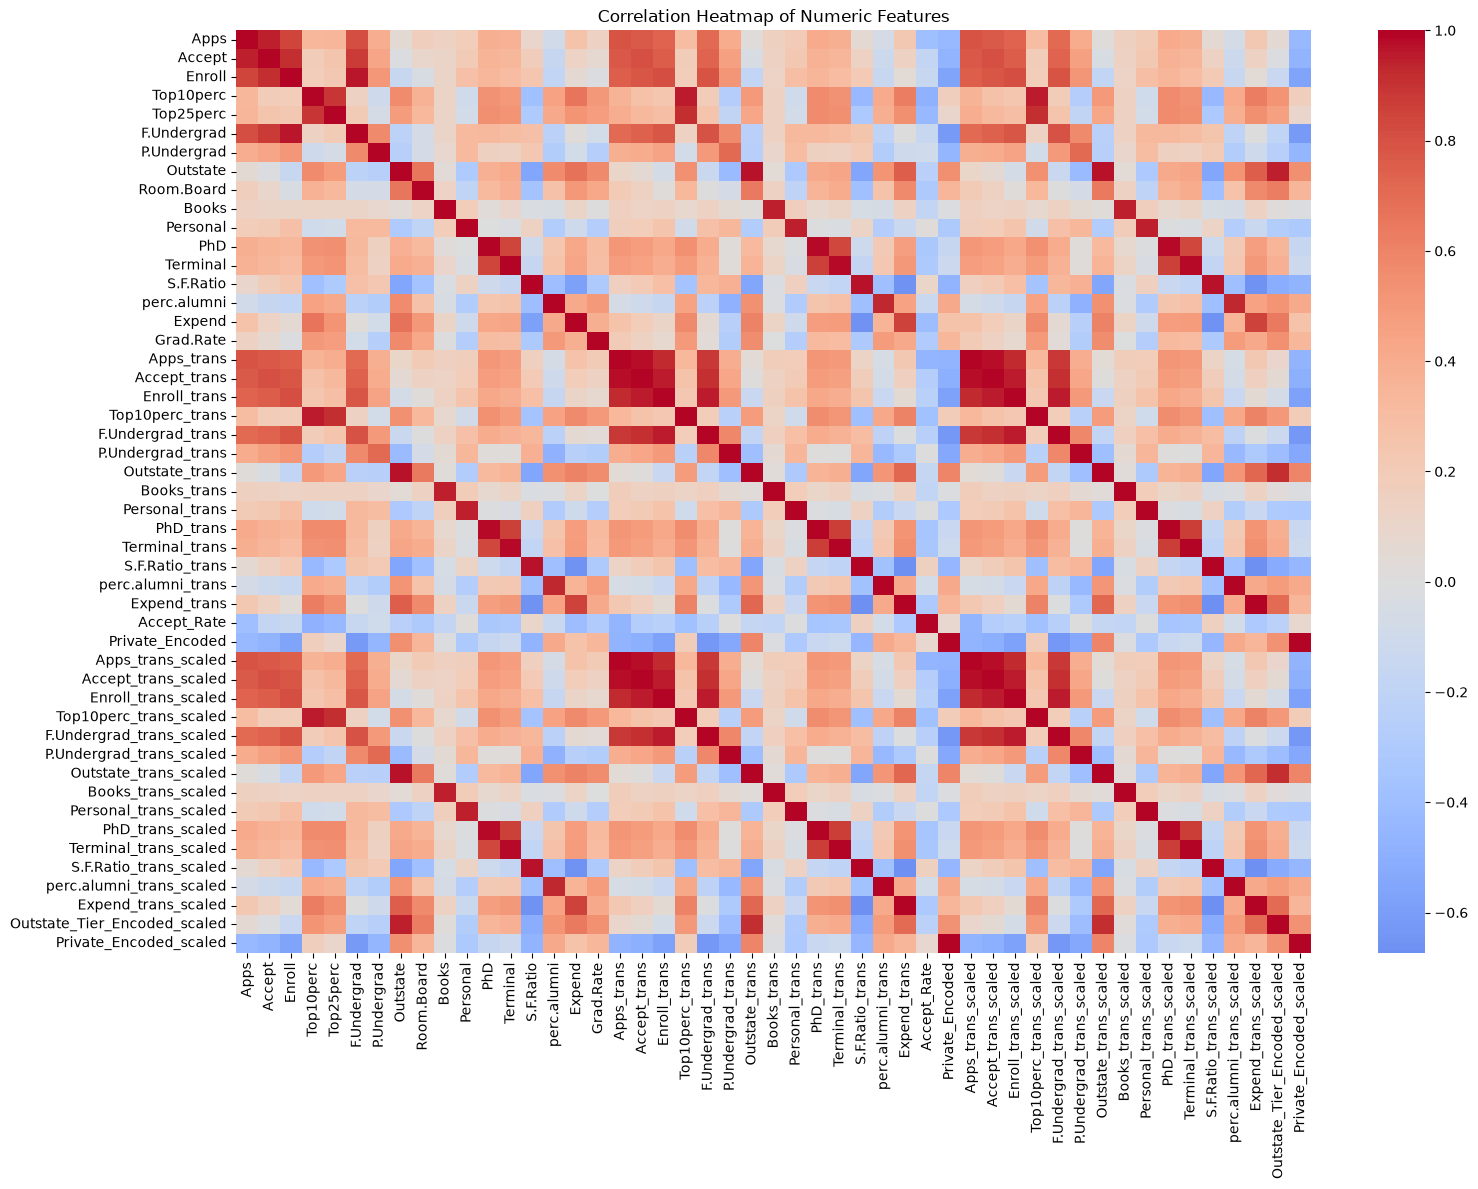

Top features related to Grad.Rate:


Outstate                        0.573612
Outstate_trans                  0.560050
Outstate_trans_scaled           0.560050
Outstate_Tier_Encoded_scaled    0.538792
Top10perc                       0.498118
Top10perc_trans_scaled          0.495577
Top10perc_trans                 0.495577
perc.alumni                     0.492887
perc.alumni_trans               0.490135
perc.alumni_trans_scaled        0.490135
Name: Grad.Rate, dtype: float64

Highly correlated features to drop:
['Accept', 'Enroll', 'Top25perc', 'F.Undergrad', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 'F.Undergrad_trans', 'Outstate_trans', 'Books_trans', 'Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Apps_trans_scaled', 'Accept_trans_scaled', 'Enroll_trans_scaled', 'Top10perc_trans_scaled', 'F.Undergrad_trans_scaled', 'P.Undergrad_trans_scaled', 'Outstate_trans_scaled', 'Books_trans_scaled', 'Personal_trans_scaled', 'PhD_trans_scaled', 'Terminal_trans_scaled', 'S.F.Ratio_trans_scaled', 'perc.alumni_trans_scaled', 'Expend_trans_scaled', 'Outstate_Tier_Encoded_scaled', 'Private_Encoded_scaled']

Original shape: (777, 53)
New shape: (777, 22)


In [117]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 12))
sns.heatmap(
    numeric_df.corr(),
    annot=False,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


grad_rate_corr = (
    numeric_df.corr()["Grad.Rate"]
    .drop("Grad.Rate")
    .abs()
    .sort_values(ascending=False)
)

print("Top features related to Grad.Rate:")
display(grad_rate_corr.head(10))


corr_matrix = numeric_df.corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper_tri.columns
    if any(upper_tri[column] > 0.85) and column != "Grad.Rate"
]

print("Highly correlated features to drop:")
print(to_drop)

df_cleaned = df.drop(columns=to_drop)

print("\nOriginal shape:", df.shape)
print("New shape:", df_cleaned.shape)

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [118]:
from sklearn.model_selection import train_test_split

target = 'Grad.Rate'

#### 15. Fit a linear regression using the raw predictors


In [119]:
all_numeric = df.select_dtypes(include=['int64', 'float64']).columns.drop(target)
original_numeric = [c for c in all_numeric if not c.endswith('_trans')]

skewed_originals = [c for c in original_numeric if abs(df[c].skew()) >= 0.5]
other_numeric = [c for c in original_numeric if abs(df[c].skew()) < 0.5]

untrans_predictors = skewed_originals + other_numeric
untrans_predictors = [c for c in untrans_predictors if c != target]

X_raw = df[untrans_predictors].fillna(df[untrans_predictors].median())
y = df[target].fillna(df[target].median())

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

lr_raw = LinearRegression()
lr_raw.fit(X_train_raw, y_train)
y_pred_raw = lr_raw.predict(X_test_raw)
r2_raw = r2_score(y_test, y_pred_raw)

print("R-squared (raw predictors):", round(r2_raw, 4))

R-squared (raw predictors): 0.3965


#### 16. Fit the same model using the log-transformed predictors

In [120]:
trans_predictors = trans_cols + other_numeric
trans_predictors = [c for c in trans_predictors if c != target]

X_trans = df[trans_predictors].fillna(df[trans_predictors].median())
y = df[target].fillna(df[target].median())

X_train_trans, X_test_trans, y_train2, y_test2 = train_test_split(
    X_trans, y, test_size=0.2, random_state=42
)

lr_trans = LinearRegression()
lr_trans.fit(X_train_trans, y_train2)
y_pred_trans = lr_trans.predict(X_test_trans)
r2_trans = r2_score(y_test2, y_pred_trans)

print("R-squared (transformed predictors):", round(r2_trans, 4))

R-squared (transformed predictors): 0.5015


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [121]:
# Your code here 
comparison = pd.DataFrame({
    'Model': ['Raw Predictors', 'Transformed Predictors'],
    'R-squared': [r2_raw, r2_trans]
})
comparison


,Model,R-squared
0,Raw Predictors,0.396468
1,Transformed Predictors,0.501519


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [122]:
# Your code here 
df.to_csv('./data/college_transformed.csv', index=False)
print("Saved college_transformed.csv with shape", df.shape)


Saved college_transformed.csv with shape (777, 53)
